In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import cv2
import os
import tqdm
import numpy as np
from torch.utils.data import DataLoader,Dataset
from PIL import Image
import torchvision.transforms.functional as TF
import zipfile

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Unzip archive.zip into a folder named "extracted"
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('extracted')

In [ ]:
train_folder_path_x = '/content/extracted/low_resolution'
train_folder_path_y = '/content/extracted/high_resolution'
data_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            data_tuple.append((image_x,image_y))

dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [ ]:


from sklearn.model_selection import train_test_split
train_tuple, test_tuple = train_test_split(data_tuple, test_size=0.1, random_state=42)
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

810
(128, 128, 3)
(512, 512, 3)


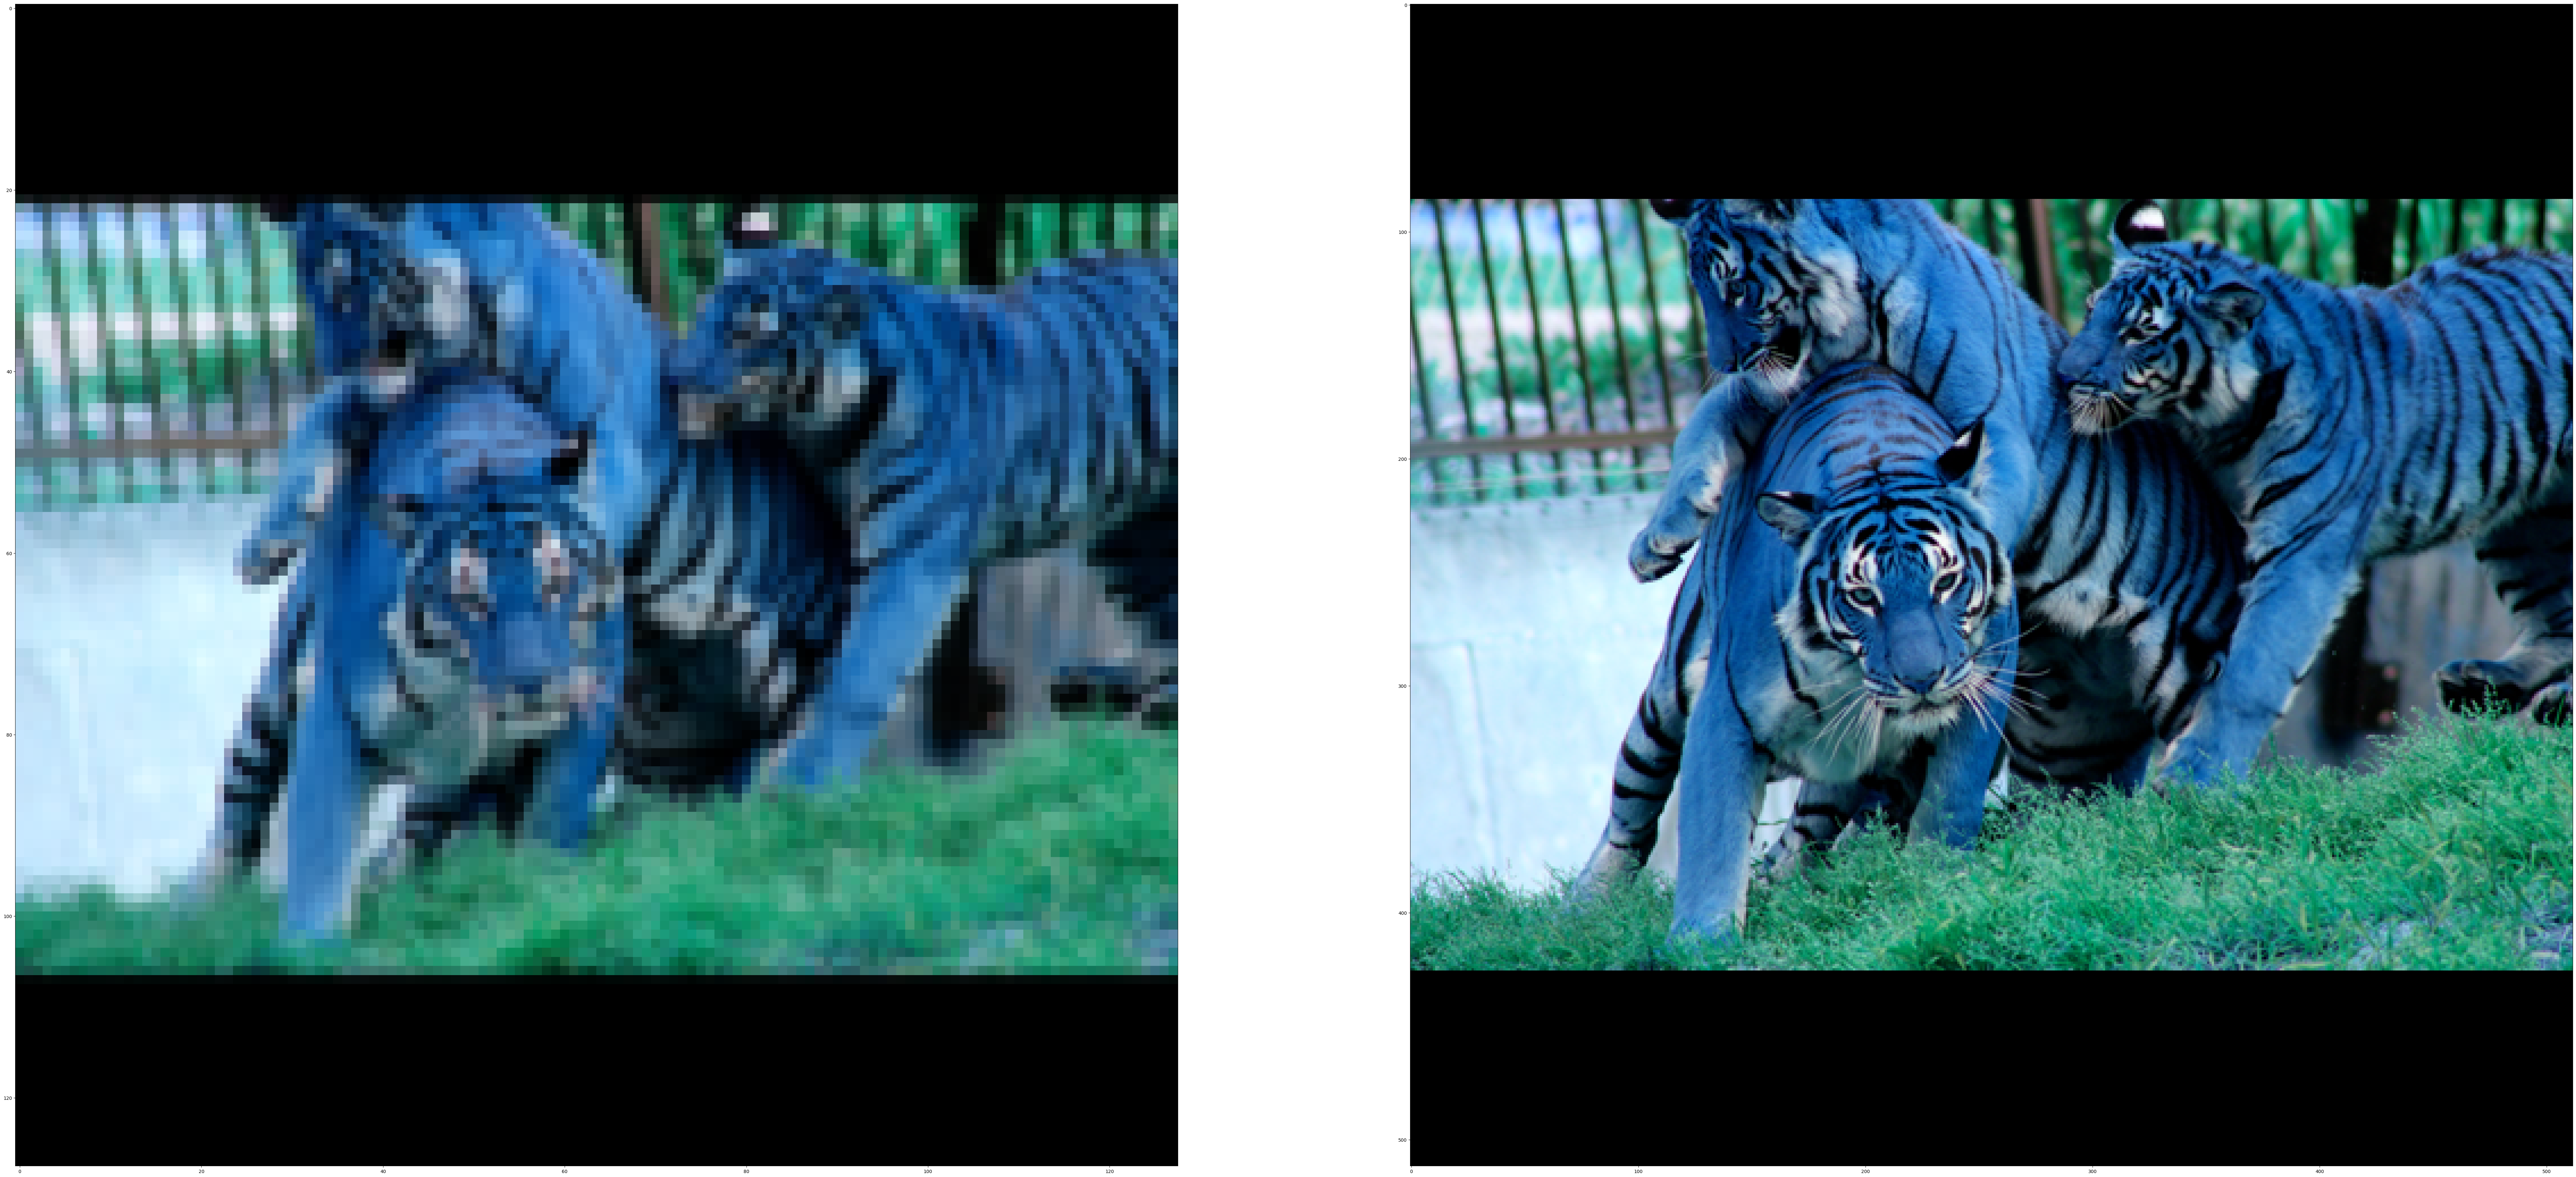

In [ ]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(train_tuple[0][0])
fig.add_subplot(1,2, 2)
plt.imshow(train_tuple[0][1])

In [ ]:
from torch.utils.data import Dataset
import cv2
import torch

class SRDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        low_res, high_res = self.data[idx]

        # Convert BGR to RGB
        low_res = cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB)
        high_res = cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB)

        # Convert to float and normalize to [0, 1]
        low_res = low_res.astype('float32') / 255.0
        high_res = high_res.astype('float32') / 255.0

        # Convert to PyTorch tensors in [C, H, W] format
        low_res = torch.from_numpy(low_res).permute(2, 0, 1)
        high_res = torch.from_numpy(high_res).permute(2, 0, 1)

        return low_res, high_res

# Create datasets and dataloaders
train_dataset = SRDataset(train_tuple)
test_dataset = SRDataset(test_tuple)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False)

In [ ]:
train_iterator = iter(train_dataloader)
batch = next(train_iterator)
inputs, labels = batch
print(inputs.shape,labels.shape)

torch.Size([4, 3, 128, 128]) torch.Size([4, 3, 512, 512])


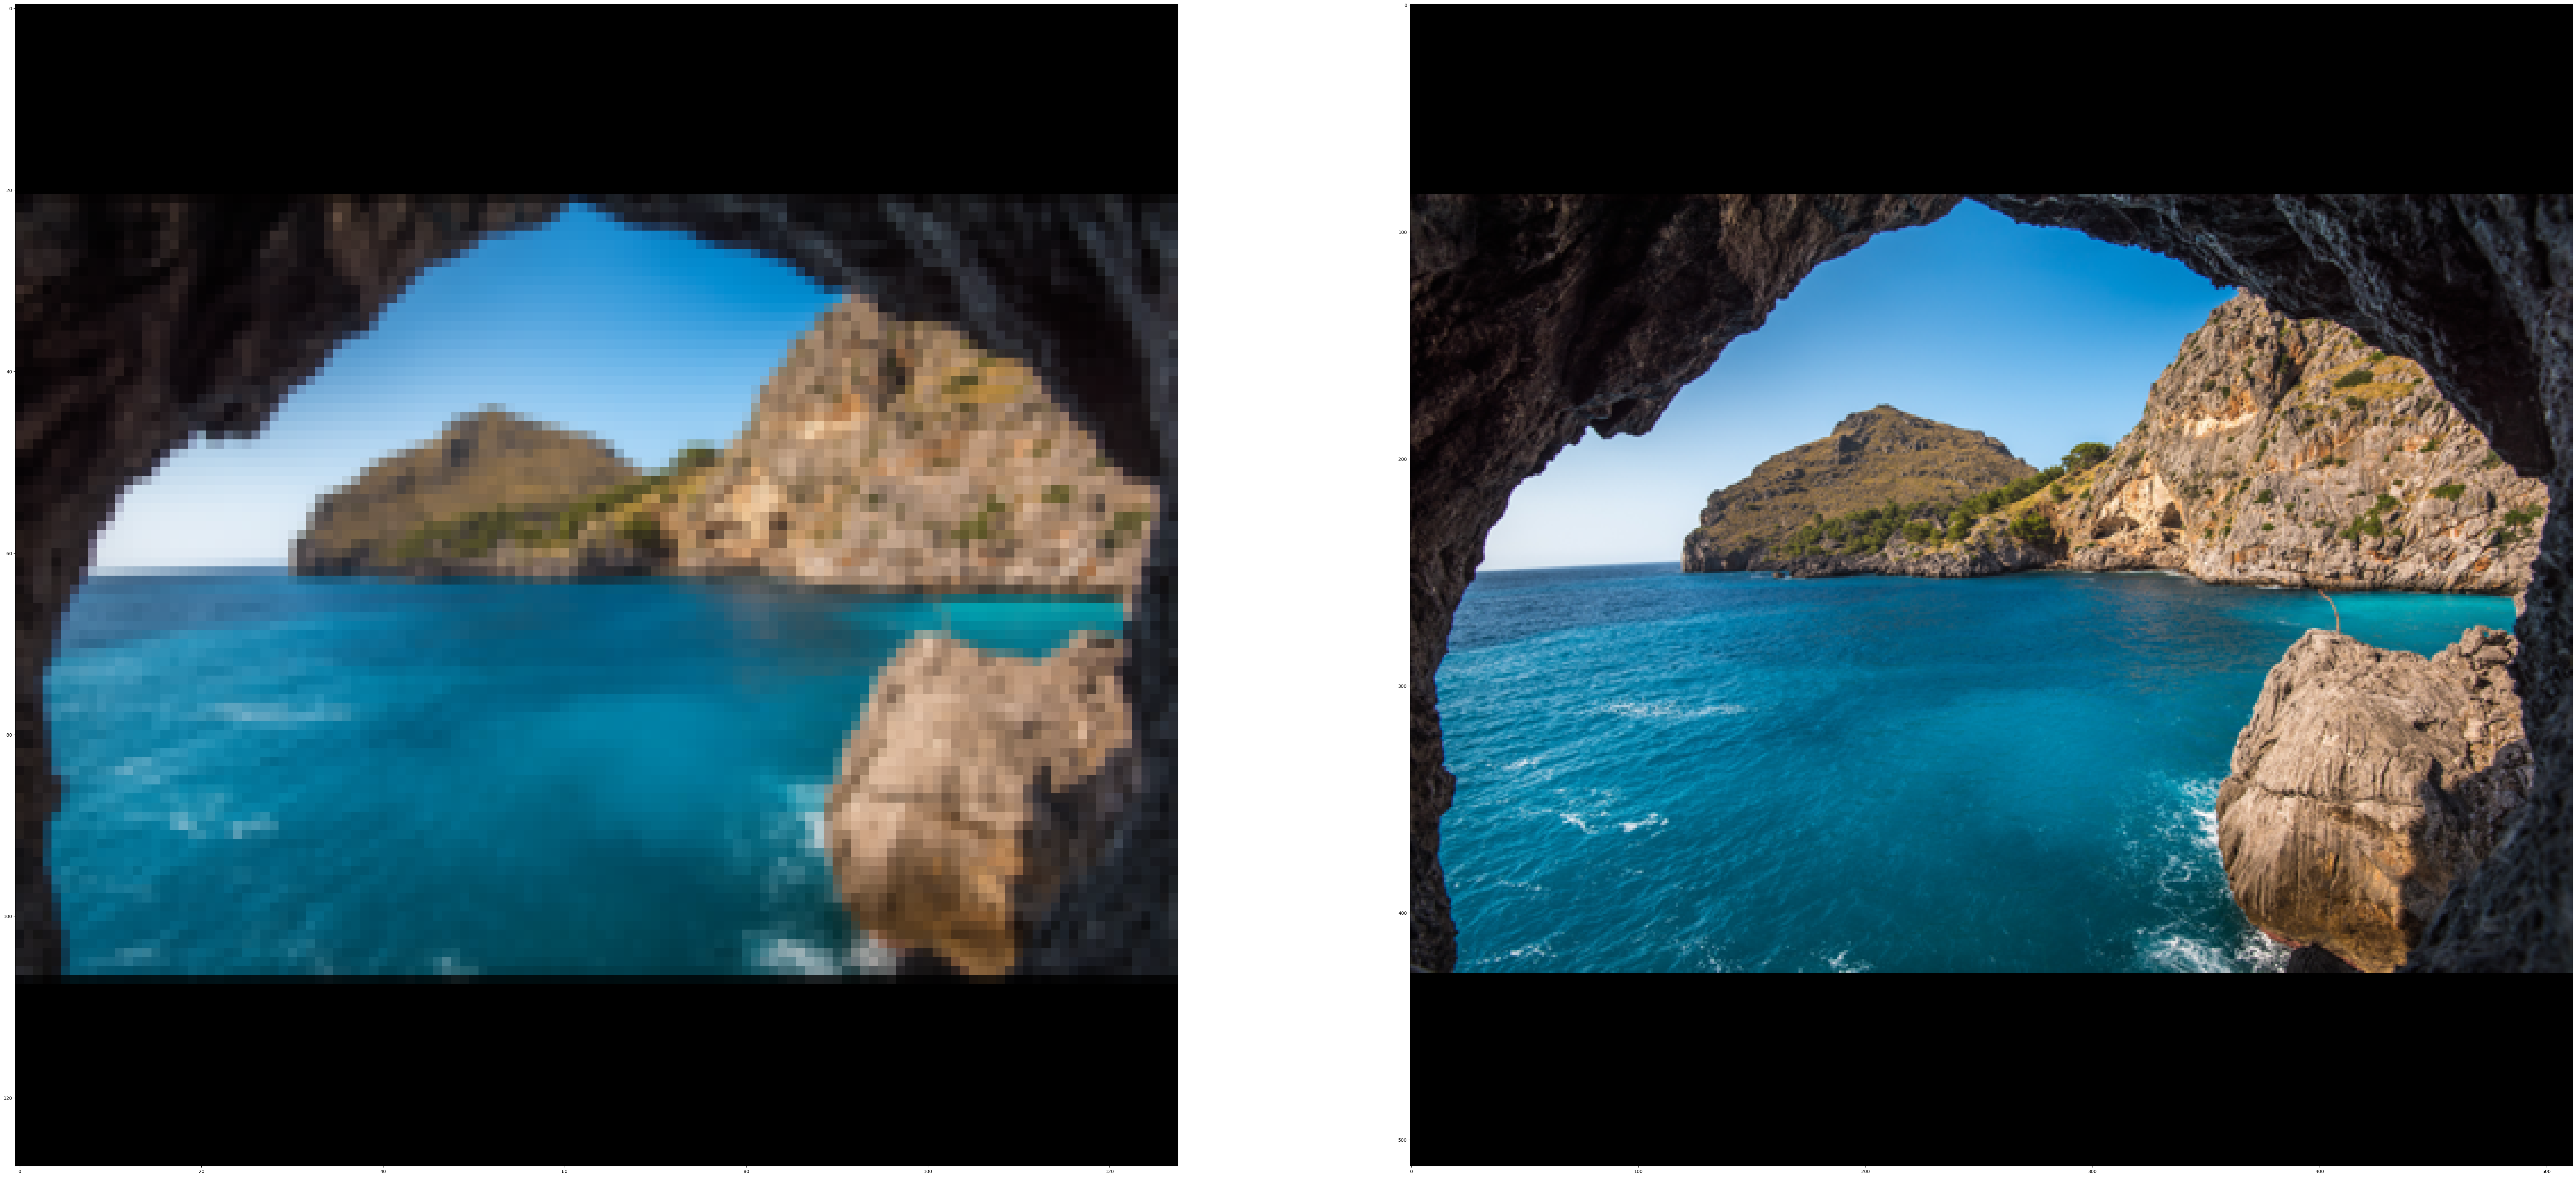

In [ ]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(inputs[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))
fig.add_subplot(1,2, 2)
plt.imshow(labels[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))

In [ ]:
class ESPCN(nn.Module):
    def __init__(self, upscale_factor):
        super(ESPCN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, (upscale_factor ** 2) * 3, kernel_size=3, padding=1)  # Handle 3-channel output
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        return x


In [ ]:
model = ESPCN(upscale_factor=4).to(device)


criterion = nn.MSELoss()
# criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-5)

In [ ]:
num_epochs = 100
training_loss = []
testing_loss = []

def train():
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_dataloader:
            x = x.to(device)  # [B, 3, 128, 128]
            y = y.to(device)  # [B, 3, 512, 512]

            recon = model(x)  # Output: [B, 3, 512, 512]
            loss = criterion(recon, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        training_loss.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # Test every 10 epochs
        if (epoch + 1) % 10 == 0:
            model.eval()
            test_loss = 0.0
            with torch.no_grad():
                for x, y in test_dataloader:
                    x = x.to(device)
                    y = y.to(device)
                    recon = model(x)
                    loss = criterion(recon, y)
                    test_loss += loss.item()

            avg_test_loss = test_loss / len(test_dataloader)
            testing_loss.append(avg_test_loss)
            print(f"→ Test Loss at Epoch {epoch+1}: {avg_test_loss:.4f}")

In [ ]:
train()

Epoch 1/100, Train Loss: 0.0151
Epoch 2/100, Train Loss: 0.0051
Epoch 3/100, Train Loss: 0.0045
Epoch 4/100, Train Loss: 0.0044
Epoch 5/100, Train Loss: 0.0040
Epoch 6/100, Train Loss: 0.0040
Epoch 7/100, Train Loss: 0.0038
Epoch 8/100, Train Loss: 0.0038
Epoch 9/100, Train Loss: 0.0039
Epoch 10/100, Train Loss: 0.0036
→ Test Loss at Epoch 10: 0.0033
Epoch 11/100, Train Loss: 0.0036
Epoch 12/100, Train Loss: 0.0035
Epoch 13/100, Train Loss: 0.0036
Epoch 14/100, Train Loss: 0.0037
Epoch 15/100, Train Loss: 0.0035
Epoch 16/100, Train Loss: 0.0036
Epoch 17/100, Train Loss: 0.0034
Epoch 18/100, Train Loss: 0.0034
Epoch 19/100, Train Loss: 0.0036
Epoch 20/100, Train Loss: 0.0035
→ Test Loss at Epoch 20: 0.0033
Epoch 21/100, Train Loss: 0.0034
Epoch 22/100, Train Loss: 0.0033
Epoch 23/100, Train Loss: 0.0033
Epoch 24/100, Train Loss: 0.0034
Epoch 25/100, Train Loss: 0.0034
Epoch 26/100, Train Loss: 0.0034
Epoch 27/100, Train Loss: 0.0033
Epoch 28/100, Train Loss: 0.0033
Epoch 29/100, Train L

In [ ]:
state = {
    'epoch': num_epochs,
    'state_dict': model.state_dict(),
    'optimizer': optimizer.state_dict(),
}
filepath = "/content/model_auto.pth"
torch.save(state, filepath)

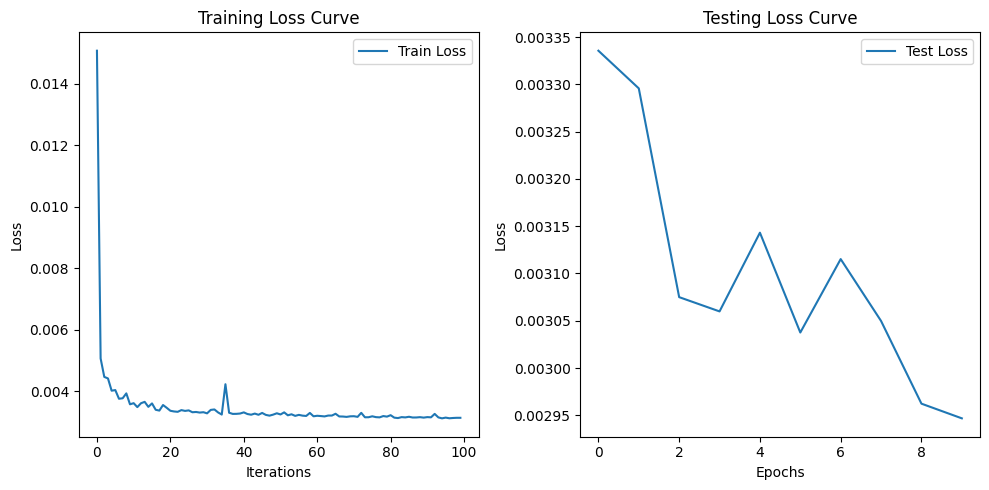

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(training_loss)), training_loss, label='Train Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(testing_loss)), testing_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Testing Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def train_result(index):
    x, y = train_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to torch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)
    y = torch.from_numpy(y).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        y_fake = model(x)

    # Move data to CPU for visualization
    x_cpu = x[0].permute(1, 2, 0).cpu().numpy()
    y_cpu = y[0].permute(1, 2, 0).cpu().numpy()
    y_fake_cpu = y_fake[0].permute(1, 2, 0).cpu().numpy()

    # Plot the results
    fig = plt.figure(figsize=(12, 4))

    ax1 = fig.add_subplot(1, 3, 1)
    ax1.set_title("Input (Low-res)")
    ax1.imshow(x_cpu)
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.set_title("Ground Truth (High-res)")
    ax2.imshow(y_cpu)
    ax2.axis("off")

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_title("Model Output")
    ax3.imshow(y_fake_cpu)
    ax3.axis("off")

    plt.tight_layout()
    plt.show()

    model.train()


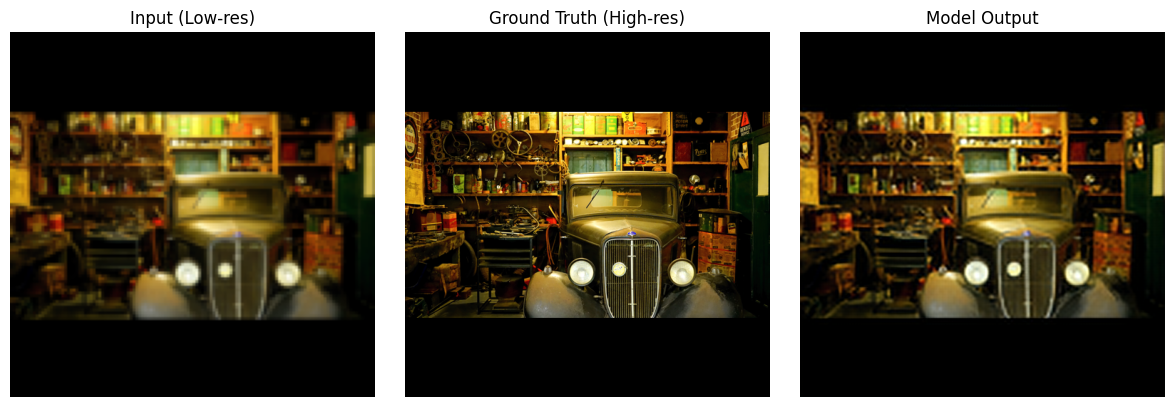

In [ ]:
train_result(11)

In [ ]:
import torch
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

model.eval()
for index in range(len(test_tuple)):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format and add batch dimension
    x_tensor = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)
    y_tensor = torch.from_numpy(y).permute(2, 0, 1).unsqueeze(0).to(device)

    # Run model inference
    with torch.no_grad():
        y_fake = model(x_tensor)

    # Convert tensors back to NumPy arrays in [H, W, C] format for metric calculation
    y_np = y_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    y_fake_np = y_fake.squeeze().permute(1, 2, 0).cpu().numpy()

    # Clip values to valid range [0, 1]
    y_np = np.clip(y_np, 0, 1)
    y_fake_np = np.clip(y_fake_np, 0, 1)

    # Compute PSNR and SSIM metrics
    psnr_val = psnr(y_np, y_fake_np, data_range=1.0)
    ssim_val = ssim(y_np, y_fake_np, data_range=1.0, channel_axis=2)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

# Calculate and print average metrics
avg_psnr = sum(psnr_list) / len(psnr_list)
avg_ssim = sum(ssim_list) / len(ssim_list)

print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average SSIM: {avg_ssim:.4f}")


Average PSNR: 26.3795
Average SSIM: 0.8139
